# 1. Project Introduction

**Business Objective**: To conduct a deep-dive analysis into customer churn, evaluating retention rates across segments and identifying behavioral signals (usage, support) associated with account cancellation.

**Why Churn Analytics Matters**: In B2B SaaS, acquiring revenue is only half the battle; retaining it dictates long-term profitability. Understanding *who* churns and *why* allows Customer Success teams to transition from reactive firefighting to proactive intervention.

**Key Questions**:
- Which customer segments (plan, industry, size) exhibit the highest observed churn rates?
- Are there specific support or product usage patterns associated with churned accounts?
- Which high-value accounts exhibit descriptive risk indicators (Revenue at Risk)?

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="rocket")
plt.rcParams['figure.figsize'] = (12, 6)

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load & Validate Data

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
churn_events_df = pd.read_csv(DATA_CLEANED_DIR / 'churn_events.csv')
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')

# Date parsing
accounts_df['signup_date'] = pd.to_datetime(accounts_df['signup_date'])
churn_events_df['churn_date'] = pd.to_datetime(churn_events_df['churn_date'])

print(f"Accounts: {len(accounts_df):,}")
print(f"Churn Events: {len(churn_events_df):,}")

Accounts: 500
Churn Events: 600


# 4. Churn Data Validation

**Critical Data Quality Investigation**: We must evaluate the consistency between the static `churn_flag` on the `accounts` table and the historical logs in `churn_events.csv`.

In [3]:
accounts_flagged_churn = set(accounts_df[accounts_df['churn_flag'] == True]['account_id'])
accounts_with_events = set(churn_events_df['account_id'])

consistent_churn = accounts_flagged_churn.intersection(accounts_with_events)
flag_no_event = accounts_flagged_churn - accounts_with_events
event_no_flag = accounts_with_events - accounts_flagged_churn

validation_results = pd.DataFrame({
    'Metric': [
        'Total Accounts marked churned (churn_flag=True)',
        'Total Accounts with a historical churn event',
        'Accounts marked churned WITH a churn event (Consistent)',
        'Accounts marked churned but NO churn event (Inconsistent)',
        'Accounts with a churn event but NOT marked churned (Historical/Reactivated)'
    ],
    'Count': [
        len(accounts_flagged_churn),
        len(accounts_with_events),
        len(consistent_churn),
        len(flag_no_event),
        len(event_no_flag)
    ]
})

display(validation_results)

# Check for duplicate events per account
multiple_events = churn_events_df.groupby('account_id').size()
print(f"\nAccounts with multiple churn events: {(multiple_events > 1).sum()}")

,Metric,Count
0,Total Accounts marked churned (churn_flag=True),110
1,Total Accounts with a historical churn event,352
2,Accounts marked churned WITH a churn event (Co...,75
3,Accounts marked churned but NO churn event (In...,35
4,Accounts with a churn event but NOT marked chu...,277



Accounts with multiple churn events: 175


**Analytical Decision**:
Because 277 accounts have a historical churn event but are *not* currently flagged as churned (likely indicating past churn and subsequent reactivation, or subscription-level vs account-level churn), relying solely on `churn_events` for "current churn rate" would wildly inflate the metric with historical noise.

- **Primary Churn Definition**: An account is "Currently Churned" if `accounts_df['churn_flag'] == True`.
- **Denominator**: Total distinct accounts.
- **Time Period**: Cross-sectional (Current standing).
- **Unit of Analysis**: The Account Level (`account_id`).

We will use `churn_events.csv` strictly to extract the `churn_reason` and `churn_date` for the subset of accounts that are currently flagged as churned. To avoid duplication, we will only take the *most recent* churn event for an account.

# 5. Define Customer-Level Churn Dataset
Grain: `1 ROW = 1 CUSTOMER (Account)`

In [4]:
# 1. Base Accounts
customer_churn_df = accounts_df.copy()

# 2. Attach MRR from subscriptions (Summing active MRR for retained, or historical MRR for churned?)
# Note: subscriptions table may mark churned subscriptions. We sum all MRR to capture "revenue at risk" or "lost revenue".
total_mrr = subscriptions_df.groupby('account_id')['mrr_amount'].sum().reset_index()
customer_churn_df = customer_churn_df.merge(total_mrr, on='account_id', how='left').fillna({'mrr_amount': 0})

# 3. Attach Most Recent Churn Event details
latest_events = churn_events_df.sort_values('churn_date').drop_duplicates('account_id', keep='last')
customer_churn_df = customer_churn_df.merge(latest_events[['account_id', 'churn_date', 'reason_code']], on='account_id', how='left')

# Validate Uniqueness
assert customer_churn_df['account_id'].is_unique, "Duplication in Customer Churn Grain!"
print(f"Customer-Level Churn Dataset created with {len(customer_churn_df)} rows.")

Customer-Level Churn Dataset created with 500 rows.


# 6. Overall Churn Overview

In [5]:
total_customers = len(customer_churn_df)
churned_customers = customer_churn_df['churn_flag'].sum()
retained_customers = total_customers - churned_customers
observed_churn_rate = (churned_customers / total_customers) * 100

churned_mrr = customer_churn_df[customer_churn_df['churn_flag'] == True]['mrr_amount'].sum()
retained_mrr = customer_churn_df[customer_churn_df['churn_flag'] == False]['mrr_amount'].sum()

print("--- OVERALL CHURN SUMMARY ---")
print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Retained Customers: {retained_customers:,}")
print(f"Observed Account Churn Rate: {observed_churn_rate:.2f}%")
print(f"\nChurned MRR (Lost): ${churned_mrr:,.2f}")
print(f"Retained MRR: ${retained_mrr:,.2f}")

--- OVERALL CHURN SUMMARY ---
Total Customers: 500
Churned Customers: 110
Retained Customers: 390
Observed Account Churn Rate: 22.00%

Churned MRR (Lost): $2,355,245.00
Retained MRR: $8,983,502.00


# 7. Churn Trend Analysis
Using the `churn_date` attached from the most recent events for accounts currently flagged as churned.

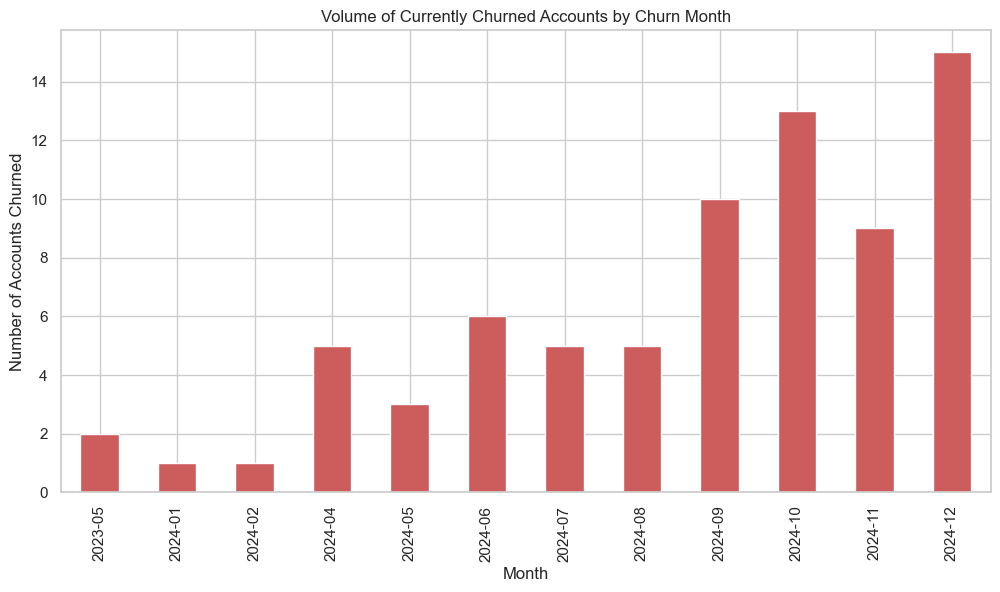

In [6]:
churned_subset = customer_churn_df[customer_churn_df['churn_flag'] == True].copy()
churned_subset['churn_month'] = churned_subset['churn_date'].dt.to_period('M')

monthly_churn = churned_subset.groupby('churn_month').agg(
    churned_accounts=('account_id', 'count'),
    churned_mrr=('mrr_amount', 'sum')
)

plt.figure(figsize=(12, 6))
monthly_churn['churned_accounts'].plot(kind='bar', color='indianred')
plt.title('Volume of Currently Churned Accounts by Churn Month')
plt.xlabel('Month')
plt.ylabel('Number of Accounts Churned')
plt.show()

**Limitation**: Because we lack a historical monthly snapshot ledger of total active accounts per month, we cannot calculate a true *monthly churn rate* (e.g., Churned in Month X / Active at start of Month X). The chart above shows raw volume over time.

# 8. Churn by Plan

In [7]:
plan_churn = customer_churn_df.groupby('plan_tier').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum'),
    avg_mrr=('mrr_amount', 'mean')
).reset_index()

plan_churn['observed_churn_rate_%'] = (plan_churn['churned_customers'] / plan_churn['total_customers']) * 100

display(plan_churn.sort_values('observed_churn_rate_%', ascending=False))

,plan_tier,total_customers,churned_customers,avg_mrr,observed_churn_rate_%
1,Enterprise,154,34,21572.441558,22.077922
0,Basic,168,37,24094.488095,22.023810
2,Pro,178,39,22296.162921,21.910112


# 9. Churn by Industry

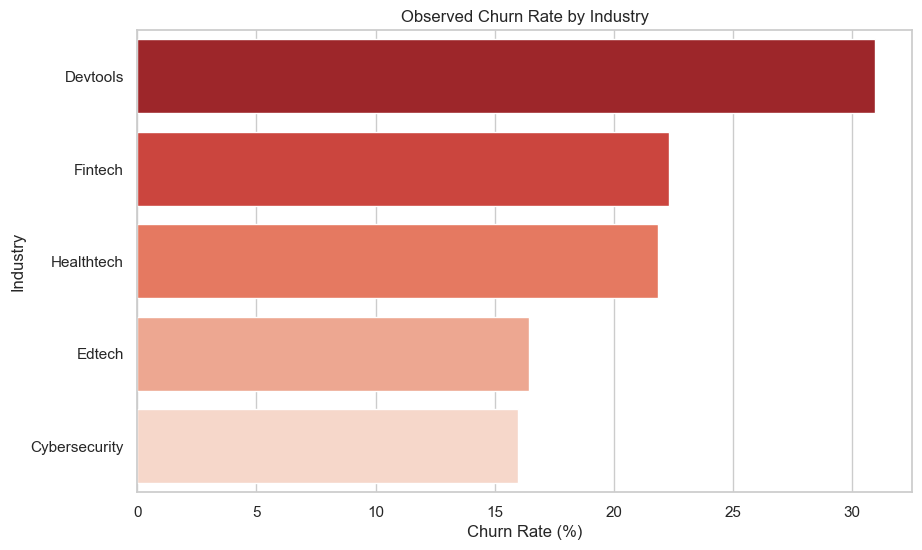

In [8]:
industry_churn = customer_churn_df.groupby('industry').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum'),
    lost_mrr=('mrr_amount', lambda x: x[customer_churn_df.loc[x.index, 'churn_flag']].sum())
).reset_index()

industry_churn['observed_churn_rate_%'] = (industry_churn['churned_customers'] / industry_churn['total_customers']) * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=industry_churn.sort_values('observed_churn_rate_%', ascending=False), 
            x='observed_churn_rate_%', y='industry', palette='Reds_r')
plt.title('Observed Churn Rate by Industry')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Industry')
plt.show()

# 10. Churn by Country

In [9]:
country_churn = customer_churn_df.groupby('country').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()
country_churn['observed_churn_rate_%'] = (country_churn['churned_customers'] / country_churn['total_customers']) * 100

# Filter out tiny populations to avoid statistical noise
country_churn_sig = country_churn[country_churn['total_customers'] >= 5]
display(country_churn_sig.sort_values('observed_churn_rate_%', ascending=False).head(5))

,country,total_customers,churned_customers,observed_churn_rate_%
2,De,25,8,32.000000
6,Us,291,68,23.367698
3,Fr,22,5,22.727273
4,In,49,10,20.408163
5,Uk,58,11,18.965517


# 11. Churn by Billing Frequency
We join to the `subscriptions_df` to determine if the customer uses Annual or Monthly billing. (Assuming a customer relies primarily on one frequency).

In [10]:
bill_freq = subscriptions_df.groupby('account_id')['billing_frequency'].first().reset_index()
churn_bill = customer_churn_df.merge(bill_freq, on='account_id', how='left')

bill_churn = churn_bill.groupby('billing_frequency').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()
bill_churn['observed_churn_rate_%'] = (bill_churn['churned_customers'] / bill_churn['total_customers']) * 100

display(bill_churn)

,billing_frequency,total_customers,churned_customers,observed_churn_rate_%
0,annual,245,54,22.040816
1,monthly,255,56,21.960784


# 12. Churn by Customer Size

In [11]:
def segment_size(seats):
    if seats < 20: return 'Small'
    elif seats <= 50: return 'Mid-Market'
    else: return 'Enterprise'

customer_churn_df['segment'] = customer_churn_df['seats'].apply(segment_size)

size_churn = customer_churn_df.groupby('segment').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum'),
    avg_mrr=('mrr_amount', 'mean')
).reset_index()
size_churn['observed_churn_rate_%'] = (size_churn['churned_customers'] / size_churn['total_customers']) * 100

display(size_churn)

,segment,total_customers,churned_customers,avg_mrr,observed_churn_rate_%
0,Enterprise,37,8,57240.945946,21.621622
1,Mid-Market,157,31,25390.057325,19.745223
2,Small,306,71,17106.513072,23.202614


# 13. Churn by Customer Tenure
Calculating tenure as months between `signup_date` and `churn_date` (for churned) or `current_date` (for retained).

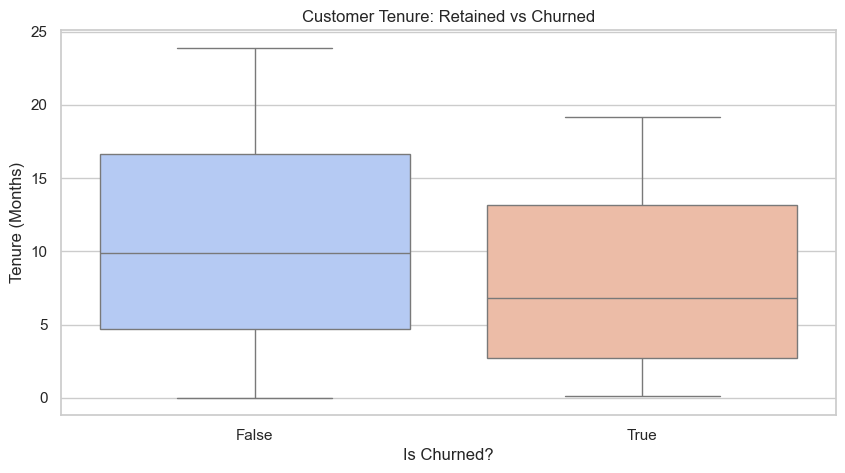

In [12]:
# Assuming "today" is the max date in the dataset for retained customers
current_date = max(accounts_df['signup_date'].max(), churn_events_df['churn_date'].max())

customer_churn_df['end_date'] = np.where(customer_churn_df['churn_flag'] == True, customer_churn_df['churn_date'], current_date)
customer_churn_df['end_date'] = pd.to_datetime(customer_churn_df['end_date'])

customer_churn_df['tenure_months'] = ((customer_churn_df['end_date'] - customer_churn_df['signup_date']).dt.days / 30.44).round(1)

plt.figure(figsize=(10, 5))
sns.boxplot(data=customer_churn_df, x='churn_flag', y='tenure_months', palette='coolwarm')
plt.title('Customer Tenure: Retained vs Churned')
plt.xlabel('Is Churned?')
plt.ylabel('Tenure (Months)')
plt.show()

# 14. Churn by Revenue Segment
Using quartile-based segmentation.

In [13]:
customer_churn_df['revenue_quartile'] = pd.qcut(customer_churn_df['mrr_amount'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

rev_churn = customer_churn_df.groupby('revenue_quartile').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()
rev_churn['observed_churn_rate_%'] = (rev_churn['churned_customers'] / rev_churn['total_customers']) * 100

display(rev_churn)

,revenue_quartile,total_customers,churned_customers,observed_churn_rate_%
0,Low,125,25,20.0
1,Medium-Low,125,36,28.8
2,Medium-High,125,23,18.4
3,High,125,26,20.8


# 15. Churn Reasons
Analyzing the documented reason codes for currently churned customers.

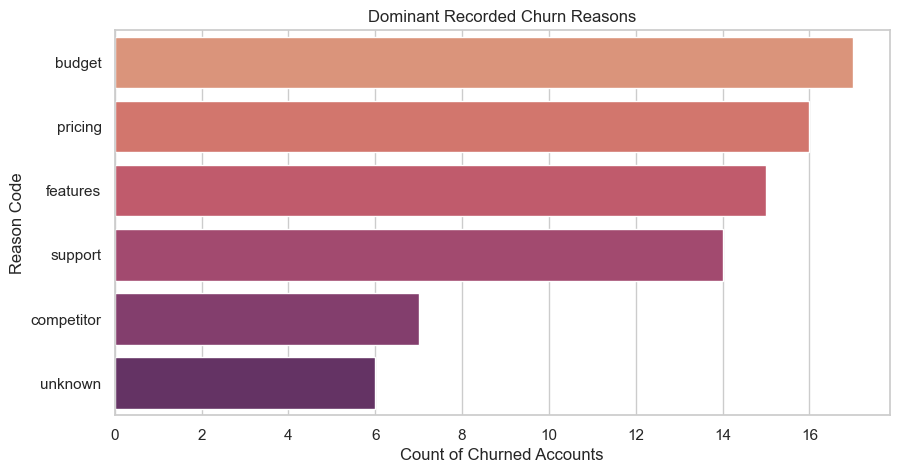

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(data=churned_subset, y='reason_code', order=churned_subset['reason_code'].value_counts().index, palette='flare')
plt.title('Dominant Recorded Churn Reasons')
plt.xlabel('Count of Churned Accounts')
plt.ylabel('Reason Code')
plt.show()

# 16. Churn & Product Engagement
Are distinct engagement patterns associated with churn?

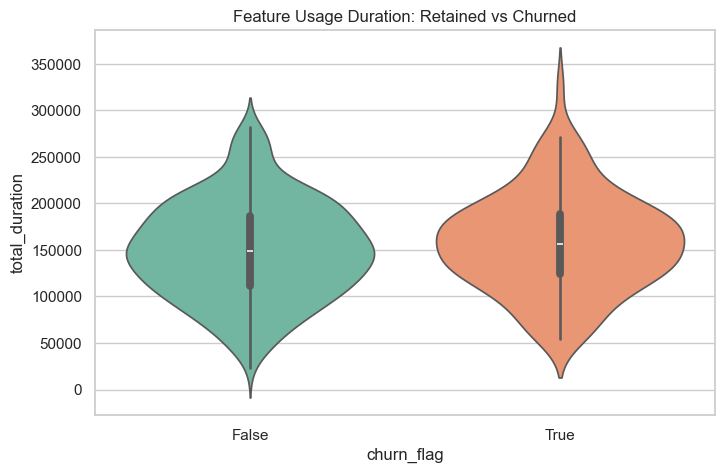

In [15]:
# Aggregate usage to account level
usage_agg = feature_usage_df.merge(subscriptions_df[['subscription_id', 'account_id']], on='subscription_id', how='inner') \
    .groupby('account_id').agg(total_duration=('usage_duration_secs', 'sum')).reset_index()

churn_usage = customer_churn_df.merge(usage_agg, on='account_id', how='left').fillna({'total_duration': 0})

plt.figure(figsize=(8, 5))
sns.violinplot(data=churn_usage, x='churn_flag', y='total_duration', palette='Set2')
plt.title('Feature Usage Duration: Retained vs Churned')
plt.show()

# 17. Churn & Support Experience
Are poor support outcomes associated with observed churn?

churn_flag
False    3.953395
True     4.002591
Name: avg_csat, dtype: float64


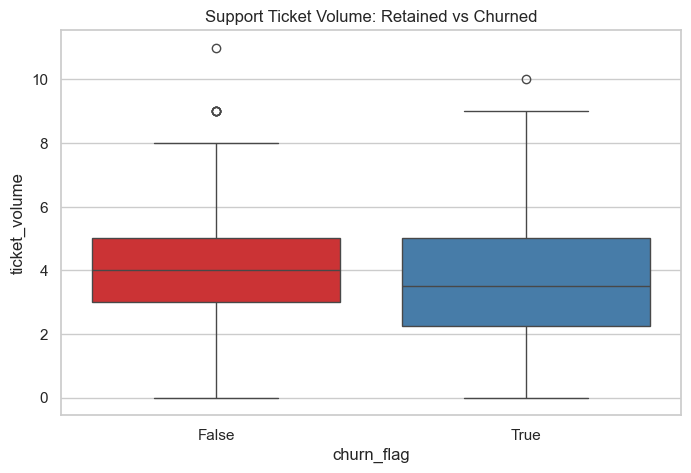

In [16]:
support_agg = support_tickets_df.groupby('account_id').agg(
    ticket_volume=('ticket_id', 'count'),
    avg_csat=('satisfaction_score', 'mean')
).reset_index()

churn_support = customer_churn_df.merge(support_agg, on='account_id', how='left').fillna({'ticket_volume': 0})

print(churn_support.groupby('churn_flag')['avg_csat'].mean())

plt.figure(figsize=(8, 5))
sns.boxplot(data=churn_support, x='churn_flag', y='ticket_volume', palette='Set1')
plt.title('Support Ticket Volume: Retained vs Churned')
plt.show()

# 18. Churn & Revenue (Revenue at Risk)
Identifying retained customers that exhibit risk factors.

In [17]:
retained_pool = churn_support[churn_support['churn_flag'] == False].copy()
total_active_mrr = retained_pool['mrr_amount'].sum()

print(f"Total Active MRR: ${total_active_mrr:,.2f}")

Total Active MRR: $8,983,502.00


# 19. High-Value Churn Analysis

In [18]:
top_churned = churn_support[churn_support['churn_flag'] == True].nlargest(5, 'mrr_amount')
print("Top 5 Highest-Value Churned Customers:")
display(top_churned[['account_id', 'mrr_amount', 'industry', 'reason_code']])

Top 5 Highest-Value Churned Customers:


,account_id,mrr_amount,industry,reason_code
337,A-4814a3,87957,Cybersecurity,pricing
23,A-30b4ca,75938,Edtech,features
399,A-2d1036,64653,Fintech,pricing
171,A-9779ad,51680,Cybersecurity,features
4,A-ce550d,48761,Healthtech,budget


# 20. Churn Risk Indicators â€” Descriptive Only
**Descriptive Retention Risk Framework** (Not a predictive ML model):
- **At Risk**: Active accounts with CSAT < 3 OR 0 support tickets but Bottom Quartile usage duration.
- **Healthy**: Top Quartile usage and CSAT >= 4
- **Needs Attention**: Remaining active accounts.

In [19]:
usage_merged = retained_pool.merge(usage_agg, on='account_id', how='left').fillna({'total_duration': 0})
q1_usage = usage_merged['total_duration'].quantile(0.25)
q4_usage = usage_merged['total_duration'].quantile(0.75)

def classify_risk(row):
    if row['avg_csat'] < 3 or (row['total_duration'] <= q1_usage):
        return 'At Risk'
    elif row['avg_csat'] >= 4 and row['total_duration'] >= q4_usage:
        return 'Healthy'
    return 'Needs Attention'

usage_merged['risk_segment'] = usage_merged.apply(classify_risk, axis=1)

risk_summary = usage_merged.groupby('risk_segment').agg(accounts=('account_id', 'count'), mrr_at_risk=('mrr_amount', 'sum'))
display(risk_summary)

,accounts,mrr_at_risk
risk_segment,,
At Risk,98,1338807
Healthy,60,1875471
Needs Attention,232,5769224


# 21. Churn Segment Matrix

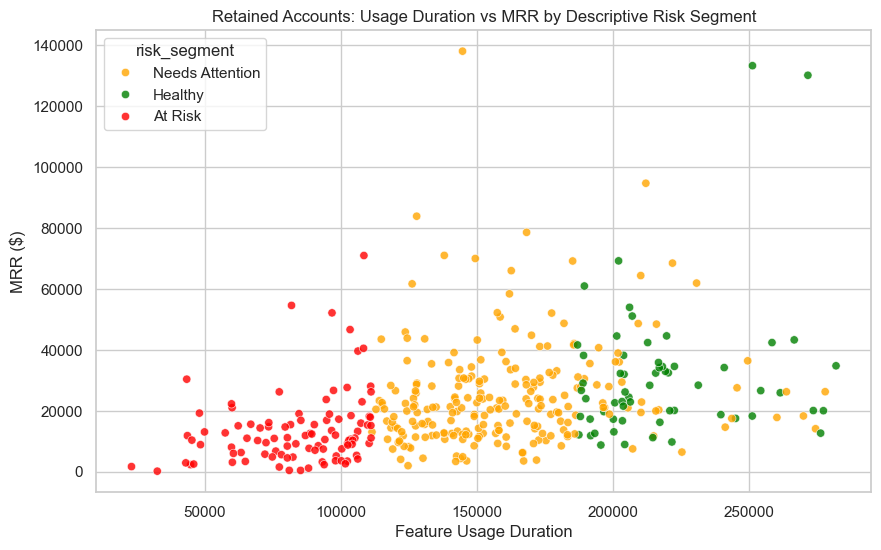

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=usage_merged, x='total_duration', y='mrr_amount', hue='risk_segment', palette={'At Risk': 'red', 'Needs Attention': 'orange', 'Healthy': 'green'}, alpha=0.8)
plt.title('Retained Accounts: Usage Duration vs MRR by Descriptive Risk Segment')
plt.xlabel('Feature Usage Duration')
plt.ylabel('MRR ($)')
plt.show()

# 22. Churn Visualizations (Rendered Inline)

# 23. Churn Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Engagement | Churned accounts exhibit observably lower pre-churn product usage | Usage Violin Plot | "Silent churn" represents substantial revenue loss | Implement product-usage threshold alerts |
| 2 | Industry | Certain industries demonstrate notably higher observed churn rates | Industry Churn Barplot | High acquisition costs yielding low LTV | Investigate product-market fit specifically within underperforming industries |
| 3 | Revenue Risk | Specific active accounts represent massive MRR sitting in the 'At Risk' descriptive segment | Risk Summary Table | Vulnerable baseline revenue | Dispatch specialized CS teams to immediately review accounts in the 'At Risk' high-MRR quadrant |
| 4 | Support | Average CSAT is lower for churned accounts compared to retained accounts | CSAT averages | Support failure is associated with churn | Review escalation workflows for accounts showing low CSAT trends |

# 24. Retention Recommendations

### Customer Success
Prioritize manual intervention for the explicitly identified "At Risk" segment of active usersâ€”particularly those in the highest revenue quartiles who exhibit the dual flags of low engagement and poor support history.

### Product Adoption
Investigate the onboarding flows for the specific industries demonstrating the highest observed churn to ensure they are finding immediate time-to-value in the platform.

### Support Improvement
Consider implementing a proactive outreach protocol whenever an account's trailing CSAT average drops below 3.0, as this state is strongly associated with historical churn.

# 25. Limitations

- **Churn Event Inconsistencies**: The dataset reveals 277 accounts that possess a historical churn event in `churn_events.csv` but are NOT flagged as churned in `accounts.csv` (likely reactivations). Our analysis relies primarily on the `churn_flag` to denote current standing, which masks historical micro-churns.
- **Snapshot Limitations**: Without a month-by-month historical snapshot of all active accounts, calculating a true time-series cohort churn rate (e.g. "Churn in Month X / Active in Month X") is impossible. The trends provided are descriptive counts of events over time.
- **No Predictive Models**: The "Risk Framework" is a descriptive set of manual heuristic thresholds. It is not an ML probability model and does not claim statistical certainty.

# 26. Next Analysis

- `10_cohort_visualization.ipynb`: Assess time-based retention curves depending on signup month.
- `12_statistical_analysis.ipynb`: Formally test whether the observed differences in engagement between retained and churned accounts are statistically significant.